# What is the most optimar skill to learn for D.A.?

### Methodology
Group skills for median salary and posting likelihood
Visualize median vs percent skill demand
Prevalent technologies

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_usa_da = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_usa_da = df_usa_da.dropna(subset=['salary_year_avg'])

In [4]:
df_explode = df_usa_da.explode('job_skills')

In [5]:
df_explode[['salary_year_avg', 'job_skills']].head(2)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r


In [12]:
df_da_skills = df_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by = 'count', ascending = False)
df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'salary_median'})

In [18]:
df_da_skills

,skill_count,salary_median
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


In [17]:
df_job_count = len(df_usa_da)


In [19]:
df_da_skills['skill_percent'] = df_da_skills['skill_count'] / df_job_count * 100 

In [20]:
df_da_skills

,skill_count,salary_median,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [21]:
skill_percent =  5

df_da_skills_high_demand = df_da_skills[ df_da_skills['skill_percent'] > skill_percent ]

df_da_skills_high_demand

,skill_count,salary_median,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


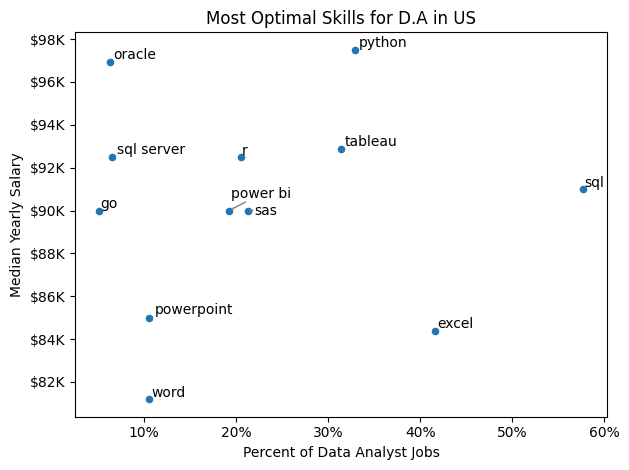

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text


ax = df_da_skills_high_demand.plot(kind='scatter', x='skill_percent', y='salary_median')


texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(
        plt.text(
            df_da_skills_high_demand['skill_percent'].iloc[i], 
            df_da_skills_high_demand['salary_median'].iloc[i], 
            txt
        )
    )


ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0)) # Set xmax=100 if skill_percent is 0-100


plt.title('Most Optimal Skills for D.A in US')
plt.ylabel('Median Yearly Salary')
plt.xlabel('Percent of Data Analyst Jobs')


adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

plt.tight_layout()
plt.show()

In [30]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

In [31]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['esquisse',
  'alteryx',
  'spreadsheet',
  'excel',
  'nuix',
  'sheets',
  'spss',
  'powerbi',
  'sharepoint',
  'dax',
  'ssrs',
  'microstrategy',
  'visio',
  'outlook',
  'ms access',
  'tableau',
  'cognos',
  'msaccess',
  'word',
  'datarobot',
  'sap',
  'looker',
  'qlik',
  'ssis',
  'sas',
  'powerpoint',
  'power bi',
  'splunk'],
 'programming': ['vba',
  'perl',
  'c',
  'lua',
  'go',
  'visualbasic',
  'dart',
  'c#',
  'c++',
  'groovy',
  'mongodb',
  'ruby',
  't-sql',
  'sql',
  'shell',
  'html',
  'mongo',
  'f#',
  'crystal',
  'matlab',
  'no-sql',
  'cobol',
  'rust',
  'kotlin',
  'haskell',
  'r',
  'visual basic',
  'css',
  'swift',
  'apl',
  'julia',
  'php',
  'clojure',
  'scala',
  'vb.net',
  'objective-c',
  'typescript',
  'golang',
  'pascal',
  'nosql',
  'fortran',
  'sas',
  'delphi',
  'java',
  'powershell',
  'bash',
  'assembly',
  'ocaml',
  'lisp',
  'elixir',
  'javascript',
  'solidity',
  'sass',
  'erlang',
  'pyt

In [32]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,esquisse
0,analyst_tools,alteryx
0,analyst_tools,spreadsheet
0,analyst_tools,excel
0,analyst_tools,nuix
...,...,...
9,sync,symphony
9,sync,unify
9,sync,twilio
9,sync,webex


In [35]:
df_plot = df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

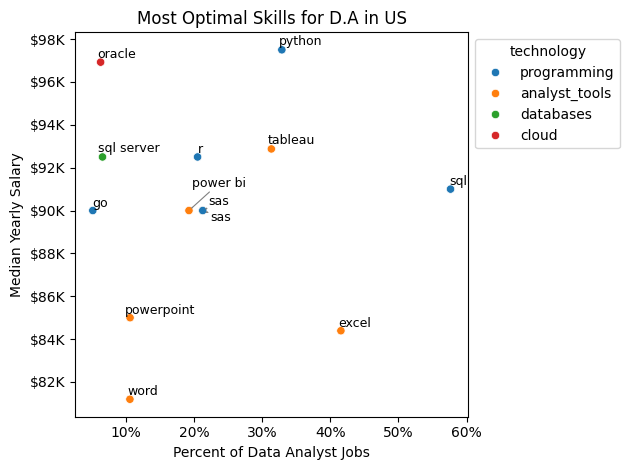

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from adjustText import adjust_text

# 1. Graficar
ax = sns.scatterplot(
    data=df_plot, 
    x='skill_percent', 
    y='salary_median',
    hue='technology'
)

# 2. Mover la leyenda fuera del gráfico para que no tape las etiquetas
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# 3. Crear etiquetas usando la columna correcta o el índice
texts = []
for i in range(len(df_plot)):
    # Reemplaza 'skills' por el nombre de tu columna si no están en el índice
    skill_name = df_plot.index[i] if 'skills' not in df_plot.columns else df_plot['skills'].iloc[i]
    
    texts.append(
        ax.text(
            df_plot['skill_percent'].iloc[i], 
            df_plot['salary_median'].iloc[i], 
            str(skill_name),
            fontsize=9
        )
    )

# 4. Formatear ejes
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# 5. Títulos y etiquetas de ejes
plt.title('Most Optimal Skills for D.A in US')
plt.ylabel('Median Yearly Salary')
plt.xlabel('Percent of Data Analyst Jobs')

# 6. Ajustar textos vinculándolos a los puntos (evita que desaparezcan)
adjust_text(
    texts, 
    x=df_plot['skill_percent'].values, 
    y=df_plot['salary_median'].values,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.8)
)

plt.tight_layout()
plt.show()